# Testing Data Retrieval and Database Building from WQP
Using WQP's webservice APIs

In [1]:
# %pip -q install pandas

In [37]:
import requests
import pandas as pd
from io import StringIO

url = "https://www.waterqualitydata.us/data/Result/search"
bbox = "-118.951721,32.75004,-117.646374,34.823302"  # la county bounding box

params = [
    # ("countrycode", "LE"),
    ("bBox", bbox),
    ("dataProfile", "resultPhysChem"),
    ("providers", "NWIS"),
    ("providers", "STORET"),
    ("mimeType", "csv"),
    ("zip", "no"),
    ("startDateLo", "01-01-2012"),
    ("startDateHi", "12-31-2022"),
]

r = requests.get(url, params=params, timeout=180)
print("STATUS:", r.status_code)
print("URL:", r.url)
print("Warning:", r.headers.get("Warning"))
print("BODY preview:", r.text[:300])

r.raise_for_status()
df = pd.read_csv(StringIO(r.text))
df.head()


STATUS: 200
URL: https://www.waterqualitydata.us/data/Result/search?bBox=-118.951721%2C32.75004%2C-117.646374%2C34.823302&dataProfile=resultPhysChem&providers=NWIS&providers=STORET&mimeType=csv&zip=no&startDateLo=01-01-2012&startDateHi=12-31-2022
BODY preview: OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,ActivityEndTime/Time,ActivityEndTime/TimeZoneCode,ActivityRelativeDepthName,Activit


/var/folders/z7/_7gxg0dx5j971t3x2y5zvc540000gn/T/ipykernel_99060/3217389424.py:27: DtypeWarning: Columns (5,9,10,11,12,14,15,17,19,20,21,22,24,27,28,34,37,38,41,43,45,47,48,49,50,59,61,62,66,70,73,74,75,76,77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(StringIO(r.text))


OrganizationIdentifier                        OrganizationFormalName  \
0           21CAOCSD_WQX  Orange County Sanitation District California   
1           21CAOCSD_WQX  Orange County Sanitation District California   
2           21CAOCSD_WQX  Orange County Sanitation District California   
3           21CAOCSD_WQX  Orange County Sanitation District California   
4           21CAOCSD_WQX  Orange County Sanitation District California   

                         ActivityIdentifier ActivityTypeCode  \
0          21CAOCSD_WQX-2012.1-WQ-Rep1-CDOM   Sample-Routine   
1      21CAOCSD_WQX-2012.1-WQ-Rep1-Salinity   Sample-Routine   
2    21CAOCSD_WQX-2012.2-WQ-Rep1-Irradiance   Sample-Routine   
3  21CAOCSD_WQX-2012.1-WQ-Rep1-Conductivity   Sample-Routine   
4  21CAOCSD_WQX-2012.1-WQ-Rep1-Conductivity   Sample-Routine   

  ActivityMediaName ActivityMediaSubdivisionName ActivityStartDate  \
0             Water                          NaN        2012-01-18   
1             Water                          NaN        2012-01-18   
2             Water                          NaN        2012-04-18   
3             Water                          NaN        2012-01-18   
4             Water                          NaN        2012-01-18   

  ActivityStartTime/Time ActivityStartTime/TimeZoneCode ActivityEndDate  ...  \
0               14:16:00                            PST             NaN  ...   
1               14:16:00                            PST             NaN  ...   
2               14:16:00                            PST             NaN  ...   
3               14:16:00                            PST             NaN  ...   
4               14:16:00                            PST             NaN  ...   

  LaboratoryName AnalysisStartDate ResultLaboratoryCommentText  \
0            NaN               NaN                         NaN   
1            NaN               NaN                         NaN   
2            NaN               NaN                         NaN   
3            NaN               NaN                         NaN   
4            NaN               NaN                         NaN   

                 ResultDetectionQuantitationLimitUrl  \
0  https://www.waterqualitydata.us/data/providers...   
1  https://www.waterqualitydata.us/data/providers...   
2                                                NaN   
3  https://www.waterqualitydata.us/data/providers...   
4                                                NaN   

  DetectionQuantitationLimitTypeName  \
0              Lower Reporting Limit   
1                    Reporting limit   
2                                NaN   
3                    Reporting limit   
4                                NaN   

  DetectionQuantitationLimitMeasure/MeasureValue  \
0                                           0.01   
1                                           0.04   
2                                            NaN   
3                                           0.04   
4                                            NaN   

   DetectionQuantitationLimitMeasure/MeasureUnitCode LabSamplePreparationUrl  \
0                                               ug/g                     NaN   
1                                                 ng                     NaN   
2                                                NaN                     NaN   
3                                                 ng                     NaN   
4                                                NaN                     NaN   

           LastUpdated ProviderName  
0  2013-02-22T13:03:49       STORET  
1  2013-02-28T14:52:48       STORET  
2  2013-02-27T12:46:19       STORET  
3  2013-02-22T16:48:58       STORET  
4  2013-02-22T16:46:06       STORET  

[5 rows x 81 columns]

In [38]:
df.shape

(730795, 81)

Note: Chicago's bounding box seems to have very little data.

## Core Columns for Trend Analysis

### Time Axis (Mandatory)
- `ActivityStartDate`
- `ActivityStartTime/Time`
- `ActivityEndDate`
- `ActivityEndTime/Time`

### Location Axis (Mandatory)
- `MonitoringLocationIdentifier`

### Location Context
- `ActivityDepthHeightMeasure/MeasureValue`
- `ActivityMediaName`

### Measurement Axis (Mandatory)
- `CharacteristicName`
- `ResultMeasureValue`
- `ResultMeasure/MeasureUnitCode`

---

## Quality Control Columns
- `ResultStatusIdentifier`
- `MeasureQualifierCode`
- `DetectionQuantitationLimitMeasure/MeasureValue`
- `ResultDetectionConditionText`

---

## Optional but Useful Columns
- `ProjectIdentifier`
- `ResultAnalyticalMethod/MethodName`
- `DataProvider`
- `ActivityDepthHeightMeasure/MeasureUnitCode`


Other potential columns:
- `ResultSampleFractionText`
- `ResultStatusIdentifier`
- `ResultAnalyticalMethod/MethodIdentifier`
- `ResultAnalyticalMethod/MethodIdentifierContext`
- `ResultAnalyticalMethod/MethodName`

- `AnalysisStartDate`
- `LastUpdated`

In [39]:
# filter only necessary columns
columns_to_keep = [
    "ActivityStartDate",
    "ActivityStartTime/Time",
    "ActivityEndDate",
    "ActivityEndTime/Time",
    "MonitoringLocationIdentifier",
    "ActivityDepthHeightMeasure/MeasureValue",
    "ActivityMediaName",
    "CharacteristicName",
    "ResultMeasureValue",
    "ResultMeasure/MeasureUnitCode",
    "ResultStatusIdentifier",
    "MeasureQualifierCode",
    "DetectionQuantitationLimitMeasure/MeasureValue",
    "ResultDetectionConditionText",
    "ProjectIdentifier",
    "ResultAnalyticalMethod/MethodName",
    "ProviderName",
    "ActivityDepthHeightMeasure/MeasureUnitCode",
]

df_target = df[columns_to_keep]
df_target.head(10), df_target.shape


(  ActivityStartDate ActivityStartTime/Time ActivityEndDate  \
 0        2012-01-18               14:16:00             NaN   
 1        2012-01-18               14:16:00             NaN   
 2        2012-04-18               14:16:00             NaN   
 3        2012-01-18               14:16:00             NaN   
 4        2012-01-18               14:16:00             NaN   
 5        2012-01-18               14:16:00             NaN   
 6        2012-04-18               14:16:00             NaN   
 7        2012-04-18               14:16:00             NaN   
 8        2012-04-18               14:16:00             NaN   
 9        2012-01-18               14:16:00             NaN   
 
   ActivityEndTime/Time MonitoringLocationIdentifier  \
 0                  NaN            21CAOCSD_WQX-2103   
 1                  NaN            21CAOCSD_WQX-2103   
 2                  NaN            21CAOCSD_WQX-2103   
 3                  NaN            21CAOCSD_WQX-2103   
 4                  NaN  

In [40]:
# %pip install matplotlib

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_wqp_characteristic_trends(df_target, char):
    data = df_target.copy()

    # basic cleaning
    data["ActivityStartDate"] = pd.to_datetime(data["ActivityStartDate"], errors="coerce")

    # ensure measurements are numeric values
    data["ResultMeasureValue"] = pd.to_numeric(data["ResultMeasureValue"], errors="coerce")

    # (optional) only keep data labeled as "accepted," note that this removes majority of data
    # data = data[data["ResultStatusIdentifier"].astype(str).str.lower().eq("accepted")]

    # drop rows missing critical fields
    data = data.dropna(subset=["ActivityStartDate", "CharacteristicName", "ResultMeasureValue"])

    print("num rows after cleaning:", len(data))
    print("unique characteristics:", data["CharacteristicName"].nunique())


    dchar = data[data["CharacteristicName"] == char].copy()

    # multiple units exist --> pick the most common unit to avoid unit-mixing in plots
    if "ResultMeasure/MeasureUnitCode" in dchar.columns:
        unit = dchar["ResultMeasure/MeasureUnitCode"].value_counts().index[0]
        dchar = dchar[dchar["ResultMeasure/MeasureUnitCode"] == unit]
    else:
        unit = None

    print("Plotting characteristic:", char, "| unit:", unit)

    # plot A: raw time series (all points)
    plt.figure()
    plt.scatter(dchar["ActivityStartDate"], dchar["ResultMeasureValue"], s=8)
    plt.xlabel("ActivityStartDate")
    plt.ylabel("ResultMeasureValue" + (f" ({unit})" if unit else ""))
    plt.title(f"Raw results over time: {char}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # plot B: monthly average trend
    monthly = (
        dchar.set_index("ActivityStartDate")["ResultMeasureValue"]
            .resample("MS")
            .mean()
            .dropna()
    )

    plt.figure()
    plt.plot(monthly.index, monthly.values)
    plt.xlabel("Month")
    plt.ylabel("Monthly mean" + (f" ({unit})" if unit else ""))
    plt.title(f"Monthly mean trend: {char}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # plot C: monthly boxplots (distribution by month), can be yearly when we have more data
    dchar["Month"] = dchar["ActivityStartDate"].dt.month

    months = list(range(1, 13))

    box_data = [
        dchar.loc[dchar["Month"] == m, "ResultMeasureValue"].dropna().values
        for m in months
    ]

    plt.figure()
    plt.boxplot(box_data, labels=months, showfliers=False)
    plt.xlabel("Month")
    plt.ylabel("ResultMeasureValue")
    plt.title(f"Monthly Distribution: {char}")
    plt.tight_layout()
    plt.show()


Note: Chicago's data looks incredibly sparse despite the bounding box being larger (139km^2).

In [42]:
# visualizations for multiple characteristics
def plot_wqp_characteristic_trends(
    df: pd.DataFrame,
    characteristics,
    date_col: str = "ActivityStartDate",
    char_col: str = "CharacteristicName",
    value_col: str = "ResultMeasureValue",
    unit_col: str = "ResultMeasure/MeasureUnitCode",
    only_accepted: bool = False,
    status_col: str = "ResultStatusIdentifier",
    choose_unit: str = "most_common",   # "most_common" or a specific unit string
    showfliers: bool = False,
    point_size: int = 8
):
    """
    For each characteristic in `characteristics`, plots:
      A) raw scatter over time
      B) monthly mean trend
      C) monthly boxplots (distribution by month)

    Notes:
      - Drops rows with missing date/characteristic/value
      - Coerces date/value types
      - Optionally filters to accepted results
      - If multiple units exist, can pick the most common unit to avoid mixing
    """
    # Normalize characteristics input
    if isinstance(characteristics, str):
        characteristics = [characteristics]

    data = df.copy()

    # Basic cleaning
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")

    if only_accepted and status_col in data.columns:
        data = data[data[status_col].astype(str).str.lower().eq("accepted")]

    # Drop rows missing critical fields
    data = data.dropna(subset=[date_col, char_col, value_col])

    print("num rows after cleaning:", len(data))
    print("unique characteristics:", data[char_col].nunique())

    for char in characteristics:
        dchar = data[data[char_col] == char].copy()

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after filtering).")
            continue

        # Unit handling
        unit = None
        if unit_col in dchar.columns:
            if choose_unit == "most_common":
                unit = dchar[unit_col].dropna().value_counts().index[0] if dchar[unit_col].notna().any() else None
                if unit is not None:
                    dchar = dchar[dchar[unit_col] == unit]
            else: 
                unit = choose_unit
                dchar = dchar[dchar[unit_col] == unit]

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after unit filter).")
            continue

        print("Plotting characteristic:", char, "| unit:", unit)

        # ---- Plot A: raw time series (scatter) ----
        plt.figure(figsize=(4, 3))
        plt.scatter(dchar[date_col], dchar[value_col], s=point_size)
        plt.xlabel(date_col)
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Raw results over time: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot B: monthly mean trend ----
        monthly = (
            dchar.set_index(date_col)[value_col]
                .resample("MS")
                .mean()
                .dropna()
        )

        plt.figure(figsize=(4, 3))
        plt.plot(monthly.index, monthly.values)
        plt.xlabel("Month")
        plt.ylabel("Monthly mean" + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly mean trend: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot C: monthly boxplots ----
        dchar["Month"] = dchar[date_col].dt.month
        months = list(range(1, 13))

        box_data = [
            dchar.loc[dchar["Month"] == m, value_col].dropna().values
            for m in months
        ]

        plt.figure(figsize=(4, 3))
        plt.boxplot(box_data, labels=months, showfliers=showfliers)
        plt.xlabel("Month")
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly distribution: {char}")
        plt.tight_layout()
        plt.show()


num rows after cleaning: 695232
unique characteristics: 851
Plotting characteristic: pH | unit: std units


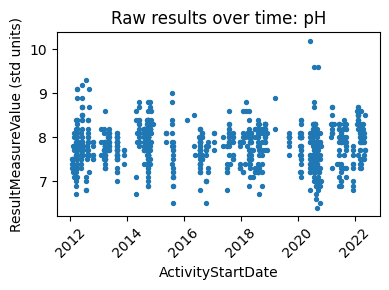

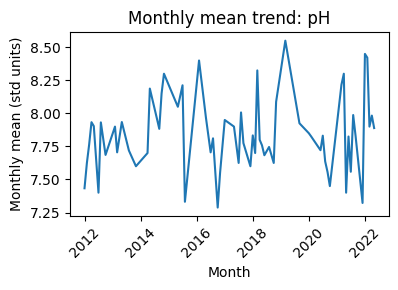

/var/folders/z7/_7gxg0dx5j971t3x2y5zvc540000gn/T/ipykernel_99060/3692876810.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


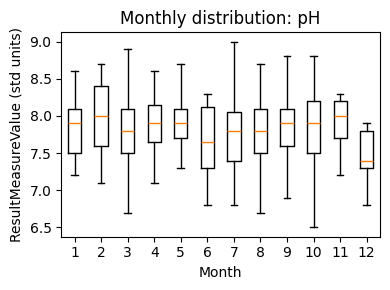

Plotting characteristic: Temperature | unit: deg C


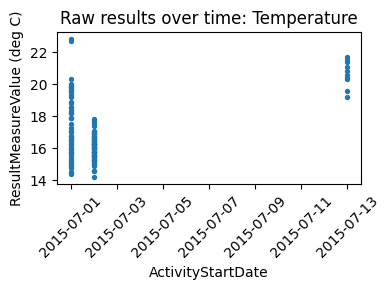

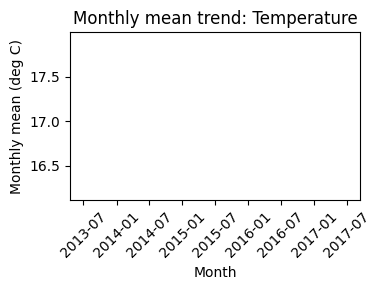

/var/folders/z7/_7gxg0dx5j971t3x2y5zvc540000gn/T/ipykernel_99060/3692876810.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


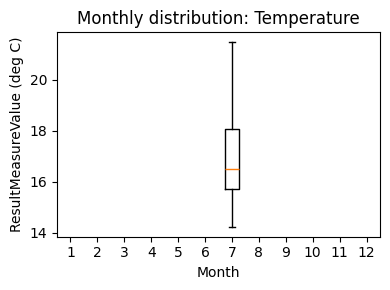

Skipping 'Temperature' (no rows after filtering).
Skipping 'water' (no rows after filtering).
Plotting characteristic: Dissolved oxygen (DO) | unit: mg/L


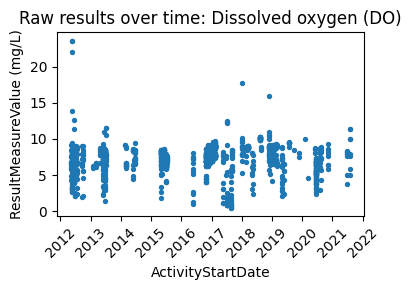

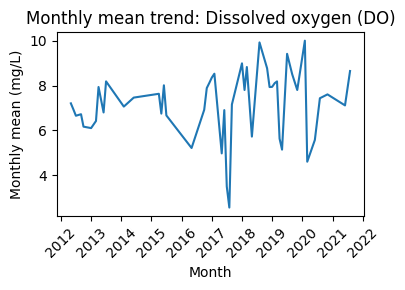

/var/folders/z7/_7gxg0dx5j971t3x2y5zvc540000gn/T/ipykernel_99060/3692876810.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


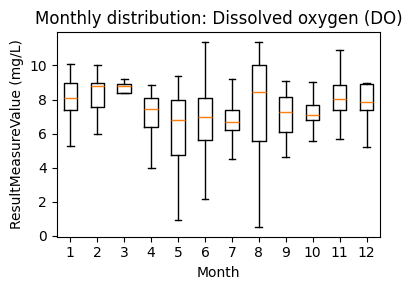

Plotting characteristic: Phosphorus | unit: mg/L


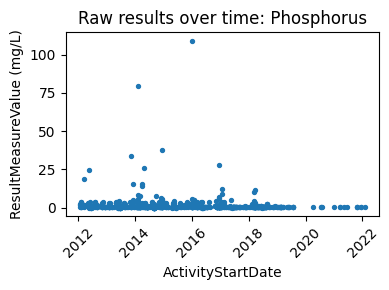

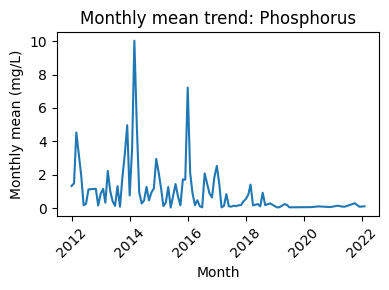

/var/folders/z7/_7gxg0dx5j971t3x2y5zvc540000gn/T/ipykernel_99060/3692876810.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


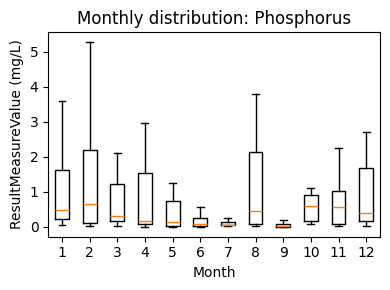

In [43]:
chars = ["pH", "Temperature", "water", "Dissolved oxygen (DO)", "Phosphorus"]
plot_wqp_characteristic_trends(df_target, chars)


In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
def plot_sampling_heatmap_and_density(df, characteristic,
                         date_col="ActivityStartDate",
                         char_col="CharacteristicName",
                         value_col="ResultMeasureValue",
                         unit_col: str = "ResultMeasure/MeasureUnitCode",
                         only_accepted: bool = False,
                         status_col: str = "ResultStatusIdentifier",
                         choose_unit: str = "most_common",):

    data = df[df[char_col] == characteristic].copy()
    data[date_col] = pd.to_datetime(data[date_col])
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")

    if only_accepted and status_col in data.columns:
        data = data[data[status_col].astype(str).str.lower().eq("accepted")]

    # Drop rows missing critical fields
    data = data.dropna(subset=[date_col, char_col, value_col])

    unit = None
    if unit_col in data.columns:
        if choose_unit == "most_common":
            unit = data[unit_col].dropna().value_counts().index[0] if data[unit_col].notna().any() else None
            if unit is not None:
                data = data[data[unit_col] == unit]
        else: 
            unit = choose_unit
            data = data[data[unit_col] == unit]

    if data.empty:
        print(f"Skipping '{characteristic}' (no rows after unit filter).")
        return

    data["year"] = data[date_col].dt.year
    data["month"] = data[date_col].dt.month

    pivot = data.pivot_table(
        index="year",
        columns="month",
        aggfunc="size",
        fill_value=0
    )

    plt.figure(figsize=(10,4))
    sns.heatmap(pivot, cmap="viridis")
    plt.title(f"Sampling frequency heatmap: {characteristic}")
    plt.xlabel("Month")
    plt.ylabel("Year")
    plt.show()


    monthly_counts = (
        data.set_index(date_col)
            .resample("MS")
            .size()
    )

    plt.figure(figsize=(6,3))
    plt.plot(monthly_counts.index, monthly_counts.values)
    plt.ylabel("Number of observations")
    plt.title(f"Sampling density: {characteristic}")
    plt.show()

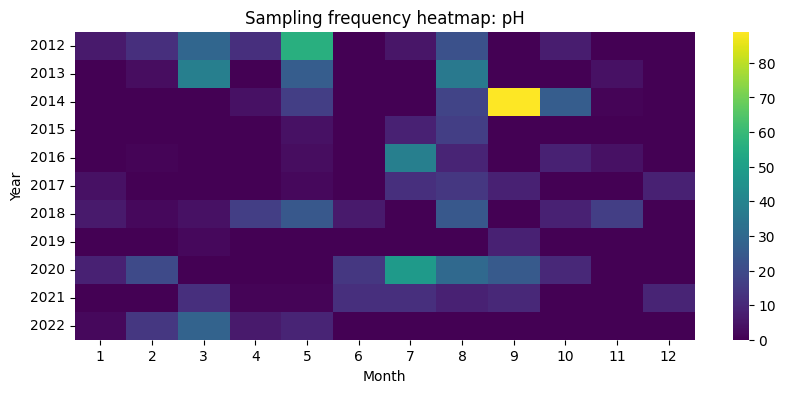

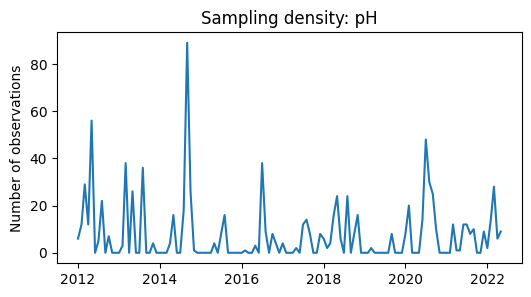

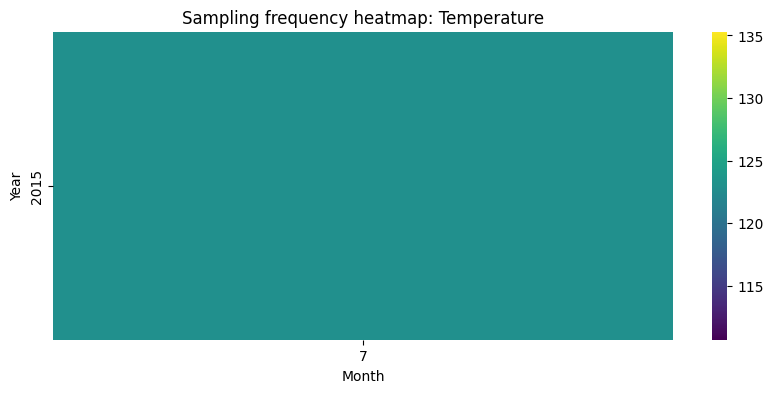

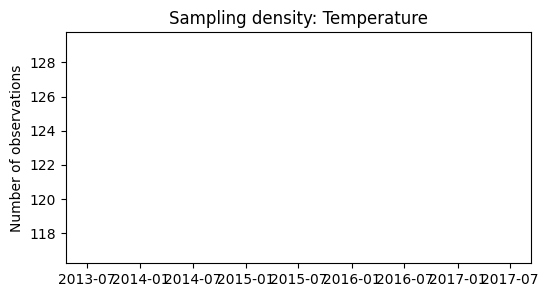

Skipping 'water' (no rows after unit filter).


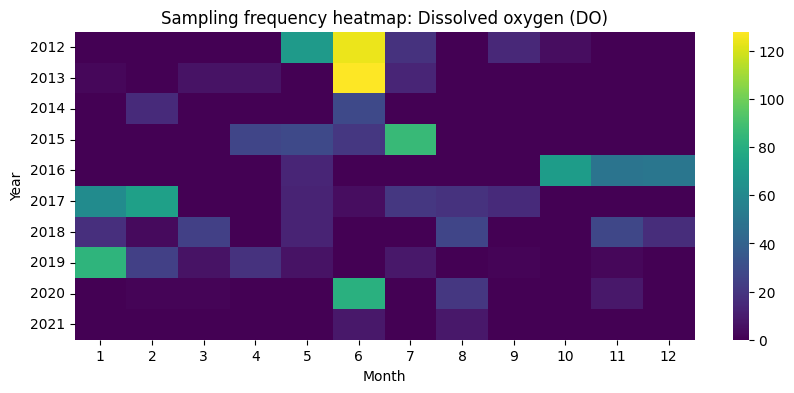

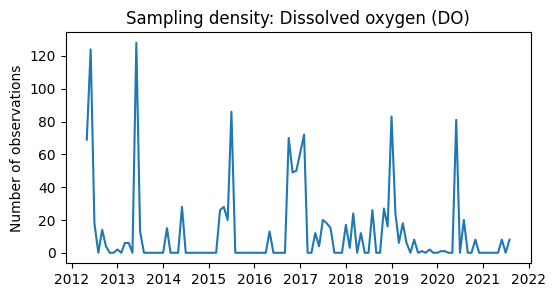

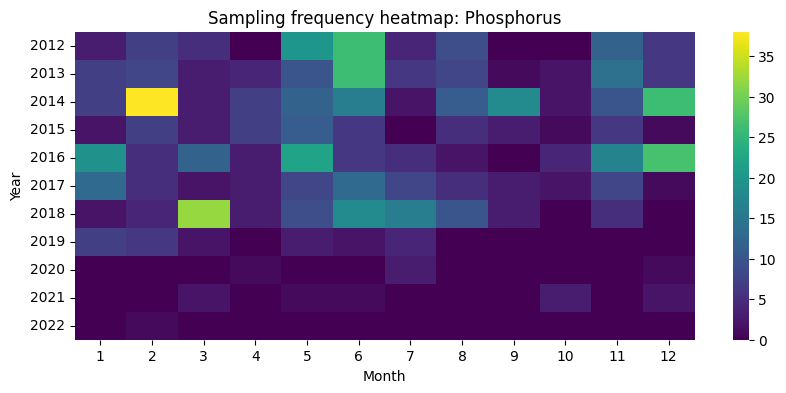

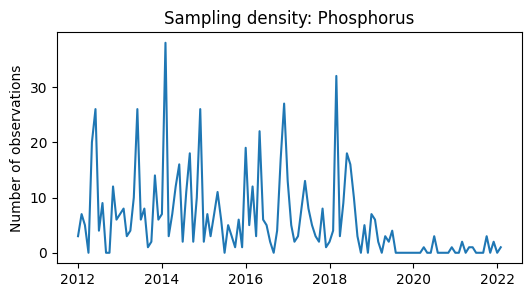

In [45]:
chars = ["pH", "Temperature", "water", "Dissolved oxygen (DO)", "Phosphorus"]
for char in chars:
    plot_sampling_heatmap_and_density(df_target, char)